In [1]:
import pandas as pd
import os

import datetime as dt

#import geopandas as gpd

import matplotlib.pyplot as plt

import numpy as np

In [4]:
pd.options.display.max_columns = None
pd.options.display.max_rows = 200

In [2]:
os.getcwd()

'/home/hector-garrido/code/github/redim-hackaton-2026'

In [3]:
import plotly.express as px

# desapariciones

In [7]:
df = pd.read_excel('data/base-dataton-2026.xlsx', sheet_name='Base')
df.head()

,Sexo,Edad,Grupo etario,Municipio,Región,Colonia/Localidad,Migrante,Fecha de desaparición,Día de la semana,Horario,Estatus,Fecha de localización,Días sin localizar,Rango desaparición,Reincidencia,Número de reincidencia,Desaparición múltiple,Persona con quién desapareció,Hipótesis,Fuente,Sistematizó,Unnamed: 21
0,Mujer,16,12 a 17,"Tuxtla Gutiérrez, Chiapas",Metropolitana,No especificado,Mestiza,2019-01-02,Martes,No especificada,No localizada,No aplica,No aplica,No aplica,No,No aplica,No,No aplica,Sin datos,¿Has visto a? Chiapas,Melel Xojobal,NaN
1,Hombre,12,12 a 17,"San Cristóbal de Las Casas, Chiapas",Altos,No especificado,Mestiza,2019-01-07,Lunes,No especificada,No localizada,No aplica,No aplica,No aplica,No,No aplica,No,No aplica,Sin datos,¿Has visto a? Chiapas,Melel Xojobal,NaN
2,Mujer,12,12 a 17,"Tuxtla Gutiérrez, Chiapas",Metropolitana,No especificado,Indígena,2019-01-07,Lunes,No especificada,Localizada,No especificada,No especificada,No especificada,No,No aplica,No,No aplica,Sin datos,¿Has visto a? Chiapas,Melel Xojobal,NaN
3,Mujer,14,12 a 17,"San Cristóbal de Las Casas, Chiapas",Altos,No especificado,Mestiza,2019-01-08,Martes,No especificada,Localizada,No especificada,No especificada,No especificada,No,No aplica,No,No aplica,Sin datos,¿Has visto a? Chiapas,Melel Xojobal,NaN
4,Mujer,15,12 a 17,"Tapachula, Chiapas",Soconusco,No especificado,Mestiza,2019-01-08,Martes,No especificada,No localizada,No aplica,No aplica,No aplica,No,No aplica,No,No aplica,Sin datos,¿Has visto a? Chiapas,Melel Xojobal,NaN


In [8]:
df['dias_sin_localizar'] = -pd.to_numeric(df['Días sin localizar'], errors='coerce').astype(int, errors='ignore')
df['semanas_sin_localizar'] = df.dias_sin_localizar // 7
#df.loc[df.semanas_sin_localizar.type == 'str','semanas_sin_localizar'] = np.nan
#df['semanas_sin_localizar'] = df['semanas_sin_localizar'] // 7
df['semanas_sin_localizar_cap'] = df['semanas_sin_localizar'].copy()
df.loc[df.semanas_sin_localizar_cap >= 7, 'semanas_sin_localizar_cap'] = 7
df['dias_sin_localizar_cap'] = df['dias_sin_localizar'].copy()
df.loc[df.dias_sin_localizar_cap >= 100, 'dias_sin_localizar_cap'] = 100

In [9]:
df['estatus'] = df['Estatus'].copy()
df['estatus'] = df['estatus'].astype(str, errors='ignore').str.lower()
df['estatus'] = df['estatus'].str.strip()
df['estatus'].value_counts()

estatus
localizada             2339
no localizada          1003
localizada sin vida      13
Name: count, dtype: int64

In [10]:
df['grupo_edad'] = df['Grupo etario'].copy()
df['grupo_edad'] = df['grupo_edad'].astype(str, errors='ignore').str.lower()
df['grupo_edad'] = df['grupo_edad'].str.strip()
df['grupo_edad'].value_counts()

grupo_edad
12 a 17    2515
0 a 5       458
6 a 11      382
Name: count, dtype: int64

In [11]:
df['sexo'] = df['Sexo'].copy()
df['sexo'] = df['sexo'].astype(str, errors='ignore').str.lower()
df['sexo'] = df['sexo'].str.strip()
df['sexo'].value_counts()

sexo
mujer     2432
hombre     923
Name: count, dtype: int64

In [47]:
df = pd.read_csv('src/data/desapariciones.csv')
df.head()

,dias_sin_localizar,semanas_sin_localizar,semanas_sin_localizar_cap,dias_sin_localizar_cap,estatus,tipo,grupo de edad,sexo,dia
0,NaN,NaN,NaN,NaN,no localizada,mestiza,12 a 17,mujer,martes
1,NaN,NaN,NaN,NaN,no localizada,mestiza,12 a 17,hombre,lunes
2,NaN,NaN,NaN,NaN,localizada,indígena,12 a 17,mujer,lunes
3,NaN,NaN,NaN,NaN,localizada,mestiza,12 a 17,mujer,martes
4,NaN,NaN,NaN,NaN,no localizada,mestiza,12 a 17,mujer,martes


In [50]:
aux = df[['grupo de edad', 'sexo']].value_counts().reset_index()
aux = aux.pivot(index='grupo de edad', columns='sexo')['count']
aux

sexo,hombre,mujer
grupo de edad,,
0 a 5,222,236
12 a 17,510,2005
6 a 11,191,191


In [53]:
px.imshow(
    aux,
    text_auto=True
    )

REDIAS
- grupos edad
- día, hora?
- indigena
- esatus?
- desaparicion multiple

Frases
- Conteo heatmap sexo edad: Las chicas adolescentes son un grupo especialmente vulnerable.
- Survival bar plot: En las desapariciones, los primeros días son críticos. 2 de cada 3 de los localizados tomaron 10 días o menos, mientras que 4 de cada 5 de los localizados tomaron 30 días o menos.
- Los NNA indígenas representan casi 2/5 de todos los NNA desaparecidos. Sin embargo, La población indígena representa 1/4 de la población total. Esto quiere decir que los NNA son 50% más vulnerables a desapariciones a comparación del resto de la población.

In [51]:
import seaborn as sns

In [52]:
sns.heatmap(
    aux.pivot(index='grupo_edad', columns='sexo')['count'], 
    annot=True, fmt='d'
    )

KeyError: "None of ['grupo_edad', 'sexo'] are in the columns"

In [54]:
df

,dias_sin_localizar,semanas_sin_localizar,semanas_sin_localizar_cap,dias_sin_localizar_cap,estatus,tipo,grupo de edad,sexo,dia
0,NaN,NaN,NaN,NaN,no localizada,mestiza,12 a 17,mujer,martes
1,NaN,NaN,NaN,NaN,no localizada,mestiza,12 a 17,hombre,lunes
2,NaN,NaN,NaN,NaN,localizada,indígena,12 a 17,mujer,lunes
3,NaN,NaN,NaN,NaN,localizada,mestiza,12 a 17,mujer,martes
4,NaN,NaN,NaN,NaN,no localizada,mestiza,12 a 17,mujer,martes
...,...,...,...,...,...,...,...,...,...
3350,1.0,0.0,0.0,1.0,localizada,mestiza,12 a 17,hombre,martes
3351,1.0,0.0,0.0,1.0,localizada,mestiza,12 a 17,hombre,martes
3352,1.0,0.0,0.0,1.0,localizada,mestiza,12 a 17,hombre,martes
3353,NaN,NaN,NaN,NaN,no localizada,mestiza,12 a 17,hombre,martes


In [ ]:
df[df.semanas_sin_localizar>=-786543].Estatus.value_counts()

Estatus
Localizada             1669
Localizada sin vida       8
No localizada             3
localizada                1
Localizada                1
Name: count, dtype: int64

In [69]:
sum(df.dias_sin_localizar<=30)

1399

In [65]:
sum(df.dias_sin_localizar>10)

579

In [67]:
sum(~df.dias_sin_localizar.isna())

1682

In [68]:
1103/1682

0.6557669441141498

In [70]:
1400/1682

0.8323424494649228

In [74]:
.38/.25

1.52

In [73]:
1268/(2062+1268)

0.38078078078078076

In [72]:
df['Migrante'].value_counts()

Migrante
Mestiza     2062
Indígena    1268
indígena      25
Name: count, dtype: int64

In [75]:
df['Estatus'].value_counts()

Estatus
Localizada             2337
No localizada          1003
Localizada sin vida      13
localizada                1
Localizada                1
Name: count, dtype: int64

In [84]:
' gfbvgfb'.strip()

'gfbvgfb'

In [81]:
df['estatus'].value_counts()

estatus
localizada             2338
no localizada          1003
localizada sin vida      13
localizada                1
Name: count, dtype: int64

In [78]:
1400/2060

0.6796116504854369

In [79]:
910/1268

0.7176656151419558

In [77]:
df[['Migrante','Estatus']].value_counts()

Migrante  Estatus            
Mestiza   Localizada             1410
Indígena  Localizada              910
Mestiza   No localizada           647
Indígena  No localizada           348
indígena  Localizada               17
Indígena  Localizada sin vida       8
indígena  No localizada             8
Mestiza   Localizada sin vida       5
Indígena  Localizada                1
          localizada                1
Name: count, dtype: int64

<Axes: xlabel='dias_sin_localizar_cap'>

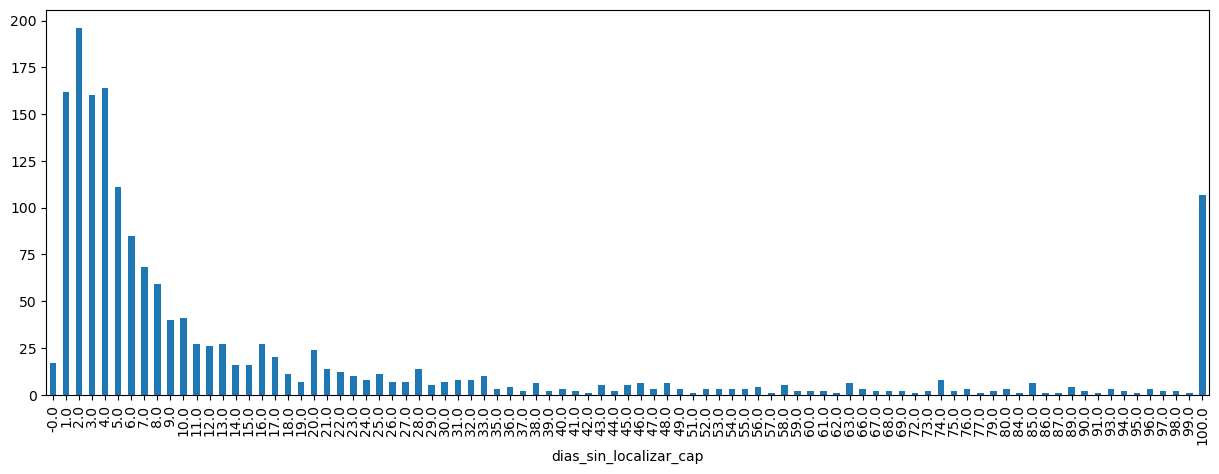

In [63]:
plt.figure(figsize=(15, 5))
df[(~df['dias_sin_localizar_cap'].isna()) ]\
    .groupby('dias_sin_localizar_cap')['Sexo'].count().plot(kind='bar')


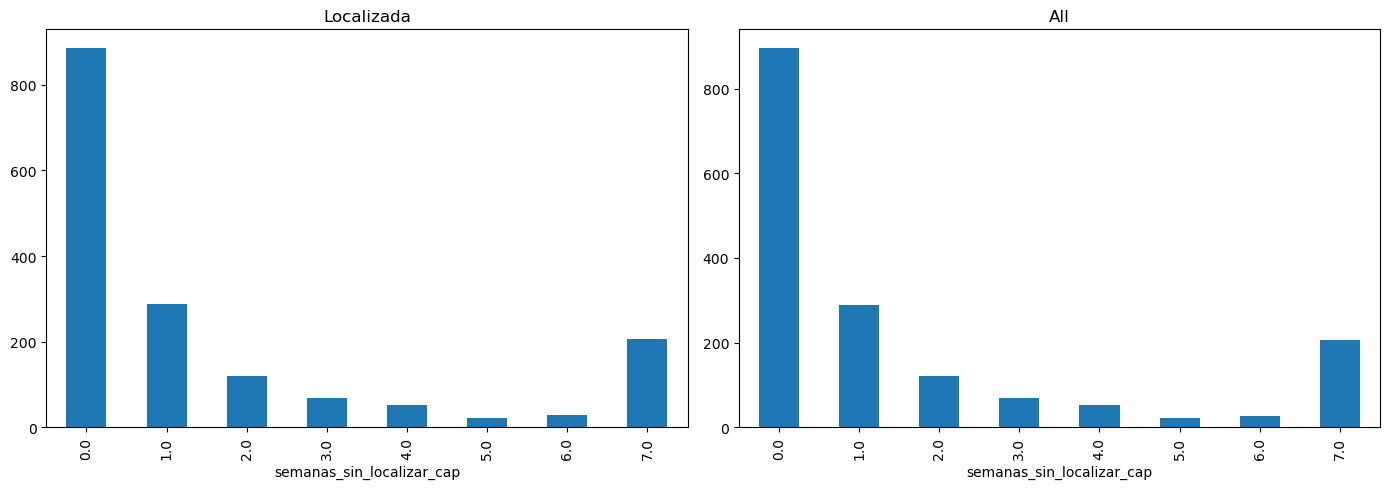

In [48]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

df[(~df['semanas_sin_localizar_cap'].isna())
   & (df.Estatus=='Localizada')]\
    .groupby('semanas_sin_localizar_cap')['Sexo'].count().plot(kind='bar', ax=ax1)
ax1.set_title('Localizada')

df[~df['semanas_sin_localizar_cap'].isna()]\
    .groupby('semanas_sin_localizar_cap')['Sexo'].count().plot(kind='bar', ax=ax2)
ax2.set_title('All')

plt.tight_layout()
plt.show()

# read files

In [5]:
path = '../scraper-sembrando-vida-test/data_2024/'

In [6]:
i = 0
for file in os.listdir(path):
    print(file)
    aux = pd.read_csv(path+file, thousands=',')
#    print(aux.shape)
    if i==0:
        df = aux
    else:
        df = pd.concat([df, aux])
    i = 1

df = df.drop_duplicates()
df = df.reset_index(drop=True)

df.head()

datos_sembrando_vida_2401_campeche.csv
datos_sembrando_vida_2401_chiapas.csv
datos_sembrando_vida_2401_chihuahua.csv
datos_sembrando_vida_2401_colima.csv
datos_sembrando_vida_2401_durango.csv
datos_sembrando_vida_2401_guerrero.csv
datos_sembrando_vida_2401_hidalgo.csv
datos_sembrando_vida_2401_jalisco.csv
datos_sembrando_vida_2401_michoacán de ocampo.csv
datos_sembrando_vida_2401_morelos.csv
datos_sembrando_vida_2401_nayarit.csv
datos_sembrando_vida_2401_oaxaca.csv
datos_sembrando_vida_2401_puebla.csv
datos_sembrando_vida_2401_quintana roo.csv
datos_sembrando_vida_2401_san luis potosí.csv
datos_sembrando_vida_2401_sinaloa.csv
datos_sembrando_vida_2401_sonora.csv
datos_sembrando_vida_2401_tabasco.csv
datos_sembrando_vida_2401_tamaulipas.csv
datos_sembrando_vida_2401_tlaxcala.csv
datos_sembrando_vida_2401_veracruz de ignacio de la llave.csv
datos_sembrando_vida_2401_yucatán.csv
datos_sembrando_vida_2401_zacatecas.csv
datos_sembrando_vida_2402_campeche.csv
datos_sembrando_vida_2402_chiapa

,periodo_ind,periodo_val,entidad_ind,entidad_val,municipio_ind,municipio_val
0,Beneficiarios del Periodo ENERO 2024,435770,Beneficiarios del Estado 04-CAMPECHE,19433,Beneficiarios del Municipio 04001-CALKINÍ,901
1,Beneficiarios del Periodo ENERO 2024,435770,Beneficiarios del Estado 04-CAMPECHE,19433,Beneficiarios del Municipio 04002-CAMPECHE,475
2,Beneficiarios del Periodo ENERO 2024,435770,Beneficiarios del Estado 04-CAMPECHE,19433,Beneficiarios del Municipio 04003-CARMEN,748
3,Beneficiarios del Periodo ENERO 2024,435770,Beneficiarios del Estado 04-CAMPECHE,19433,Beneficiarios del Municipio 04004-CHAMPOTÓN,2818
4,Beneficiarios del Periodo ENERO 2024,435770,Beneficiarios del Estado 04-CAMPECHE,19433,Beneficiarios del Municipio 04005-HECELCHAKÁN,522


In [7]:
df['fecha_str'] = df.periodo_ind.str.slice(26)

df['ano'] = df.fecha_str.str.slice(-4).astype(int)

df['mes_str'] = df.fecha_str.str.slice(stop=-5)

mes_df  = pd.DataFrame(
    data = {
        'mes_str':['ENERO','FEBRERO','MARZO','ABRIL','MAYO','JUNIO',
                   'JULIO','AGOSTO','SEPTIEMBRE','OCTUBRE','NOVIEMBRE','DICIEMBRE'],
        'mes':range(1,13)
    }
)

df = df.merge(mes_df,on='mes_str')

df['fecha'] = ''
for i in df.index:
    df.loc[i,'fecha'] = dt.date(df.ano[i],df.mes[i],1)

df['cvegeo'] = df.municipio_ind.str.slice(28,33)

df['cveent'] = df.cvegeo.str.slice(0,2)

df.head()

,periodo_ind,periodo_val,entidad_ind,entidad_val,municipio_ind,municipio_val,fecha_str,ano,mes_str,mes,fecha,cvegeo,cveent
0,Beneficiarios del Periodo ENERO 2024,435770,Beneficiarios del Estado 04-CAMPECHE,19433,Beneficiarios del Municipio 04001-CALKINÍ,901,ENERO 2024,2024,ENERO,1,2024-01-01,04001,04
1,Beneficiarios del Periodo ENERO 2024,435770,Beneficiarios del Estado 04-CAMPECHE,19433,Beneficiarios del Municipio 04002-CAMPECHE,475,ENERO 2024,2024,ENERO,1,2024-01-01,04002,04
2,Beneficiarios del Periodo ENERO 2024,435770,Beneficiarios del Estado 04-CAMPECHE,19433,Beneficiarios del Municipio 04003-CARMEN,748,ENERO 2024,2024,ENERO,1,2024-01-01,04003,04
3,Beneficiarios del Periodo ENERO 2024,435770,Beneficiarios del Estado 04-CAMPECHE,19433,Beneficiarios del Municipio 04004-CHAMPOTÓN,2818,ENERO 2024,2024,ENERO,1,2024-01-01,04004,04
4,Beneficiarios del Periodo ENERO 2024,435770,Beneficiarios del Estado 04-CAMPECHE,19433,Beneficiarios del Municipio 04005-HECELCHAKÁN,522,ENERO 2024,2024,ENERO,1,2024-01-01,04005,04


## Manual fix on 2024

In [ ]:
{
    'periodo_ind':'Beneficiarios del Periodo SEPTIEMBRE 2024',
    'periodo_val':423702,
    'entidad_ind':'Beneficiarios del Estado 20-OAXACA',
    'entidad_val':33102,
    'municipio_ind':'Beneficiarios del Municipio .....',
    'municipio_val'.:430,
}

In [8]:
output_path = "../sembrando-vida-analysis/data/sv_program_panel_data_2024.csv"
df.to_csv(output_path, index=False)

In [ ]:
df = df[df.periodo_ind!='Beneficiarios del Periodo FEBRERO 2023']

output_path = "../sembrando-vida-analysis/data/sv_program_panel_data_2.csv"

df.to_csv(output_path, index=False)

## join

In [39]:
df_1 = pd.read_csv("../sembrando-vida-analysis/data/sv_program_panel_data_1.csv")

In [57]:
df_2 = pd.read_csv("../sembrando-vida-analysis/data/sv_program_panel_data_2.csv")

In [41]:
for i in df_1.index:
    df_1.loc[i,'fecha'] = dt.datetime.strptime(df_1.loc[i,'fecha'],'%d/%m/%Y').date()

In [58]:
for i in df_2.index:
    df_2.loc[i,'fecha'] = dt.datetime.strptime(df_2.loc[i,'fecha'],'%Y-%m-%d').date()

In [59]:
df = pd.concat([df_1,df_2],ignore_index=True)

In [44]:
df\
    .sort_values(['ano','mes'])\
    .groupby(['fecha','cveent']).entidad_val.count().reset_index()\
    .pivot(index=['cveent'],columns='fecha')\
    .fillna(0)\
    .to_csv('check_edos_v7.csv')

In [65]:
df.sort_values('entidad_ind').entidad_ind.drop_duplicates()

22762          Beneficiarios del Estado 02-BAJA CALIFORNIA
2316                  Beneficiarios del Estado 04-CAMPECHE
26631     Beneficiarios del Estado 05-COAHUILA DE ZARAGOZA
9109                    Beneficiarios del Estado 06-COLIMA
39576                  Beneficiarios del Estado 07-CHIAPAS
39593                Beneficiarios del Estado 08-CHIHUAHUA
16437         Beneficiarios del Estado 09-CIUDAD DE MÉXICO
21864                  Beneficiarios del Estado 10-DURANGO
26787               Beneficiarios del Estado 11-GUANAJUATO
38678                 Beneficiarios del Estado 12-GUERRERO
31213                  Beneficiarios del Estado 13-HIDALGO
26112                  Beneficiarios del Estado 14-JALISCO
29301                   Beneficiarios del Estado 15-MÉXICO
39763      Beneficiarios del Estado 16-MICHOACÁN DE OCAMPO
6552                   Beneficiarios del Estado 17-MORELOS
29859                  Beneficiarios del Estado 18-NAYARIT
22875               Beneficiarios del Estado 19-NUEVO LE

In [66]:
'hola' in 'todo eldvfvsd hola dfnvsdlsc'

True

In [ ]:
            if link is not None:


In [67]:
os.getcwd()

'C:\\Users\\Dell\\Documents\\github\\sembrando-vida-analysis'

In [68]:
os.listdir()

['.git',
 '.gitattributes',
 '.gitignore',
 '.ipynb_checkpoints',
 '.RData',
 '.Rhistory',
 '.Rproj.user',
 'check_edos_v6.csv',
 'data',
 'diario.md',
 'dict_23_deforest_sum_1.py',
 'dict_23_deforest_sum_2.py',
 'documents_output',
 'drafts.md',
 'gardner_tablesssss_mmm.csv',
 'hector_comments.pdf',
 'images',
 'maps_plots_scraping_sv.ipynb',
 'other',
 'prem_et_al_2020_replication',
 'README.md',
 'reg_table.csv',
 'reg_table_std.csv',
 'reg_table_std_mmm.csv',
 'sat_data_sandbox.ipynb',
 'scripts',
 'sembrando-vida-analysis.Rproj']

In [69]:
%%time

with open('Tesis159816.txt', 'r', encoding='utf-8') as f:
    tesis_lol = f.read()

CPU times: total: 0 ns
Wall time: 153 ms


In [70]:
tesis_lol

'Semanario Judicial de la Federación\nTesis\nRegistro digital: 159816\nInstancia: Tribunales Colegiados\nde Circuito\n\nDécima Época\n\nMateria(s): Administrativa\n\nTesis: VI.3o.A.359 A (9a.)\n\nFuente: Gaceta del Semanario Judicial\nde la Federación.\nLibro 9, Agosto de 2014, Tomo III,\npágina 1729\n\nTipo: Aislada\n\nDERECHOS AGRARIOS. SI SU TITULARIDAD SE TRANSFIERE DE LA MISMA FORMA EN QUE\nSE TRASLADA LA PROPIEDAD DE LAS COSAS CORPORALES, LOS ACTOS RELATIVOS\nDEBEN OBSERVAR LAS REGLAS PARTICULARES DEL QUE CORRESPONDA CONFORME AL\nCÓDIGO CIVIL FEDERAL, APLICABLE SUPLETORIAMENTE A LA LEY DE LA MATERIA.\n\nDel artículo 2o. de la Ley Agraria se advierte que, en lo no previsto en dicho ordenamiento, es\nfactible acudir, supletoriamente, a la legislación civil federal. En estas condiciones, la Ley Agraria\nprevé diversas formas de transmisión de derechos que, sean de manera gratuita u onerosa,\nconfiguran actos traslativos de dominio, los cuales pueden darse en la forma de diversos con

In [62]:
df.head()

,periodo_ind,periodo_val,entidad_ind,entidad_val,municipio_ind,municipio_val,fecha_str,ano,mes_str,mes,fecha,cvegeo,cveent
0,Beneficiarios del Periodo FEBRERO 2019,54103,Beneficiarios del Estado 04-CAMPECHE,5434,Beneficiarios del Municipio 04002-CAMPECHE,1,feb-19,2019,FEBRERO,2,2019-02-01,4002,4
1,Beneficiarios del Periodo FEBRERO 2019,54103,Beneficiarios del Estado 04-CAMPECHE,5434,Beneficiarios del Municipio 04003-CARMEN,4,feb-19,2019,FEBRERO,2,2019-02-01,4003,4
2,Beneficiarios del Periodo FEBRERO 2019,54103,Beneficiarios del Estado 04-CAMPECHE,5434,Beneficiarios del Municipio 04009-ESCÁRCEGA,1296,feb-19,2019,FEBRERO,2,2019-02-01,4009,4
3,Beneficiarios del Periodo FEBRERO 2019,54103,Beneficiarios del Estado 04-CAMPECHE,5434,Beneficiarios del Municipio 04010-CALAKMUL,3914,feb-19,2019,FEBRERO,2,2019-02-01,4010,4
4,Beneficiarios del Periodo FEBRERO 2019,54103,Beneficiarios del Estado 04-CAMPECHE,5434,Beneficiarios del Municipio 04011-CANDELARIA,219,feb-19,2019,FEBRERO,2,2019-02-01,4011,4


## other

In [85]:
df\
    .sort_values('fecha')\
    .groupby(['fecha','cveent']).entidad_val.count().reset_index()\
    .pivot(index=['cveent'],columns='fecha')\
    .fillna(0)\
    .to_csv('check_edos_v5.csv')

In [77]:
df[['entidad_ind','cveent']].sort_values('cveent').drop_duplicates()

,entidad_ind,cveent
26020,Beneficiarios del Estado 02-BAJA CALIFORNIA,02
7776,Beneficiarios del Estado 04-CAMPECHE,04
6892,Beneficiarios del Estado 05-COAHUILA DE ZARAGOZA,05
17084,Beneficiarios del Estado 06-COLIMA,06
23446,Beneficiarios del Estado 07-CHIAPAS,07
8739,Beneficiarios del Estado 08-CHIHUAHUA,08
46,Beneficiarios del Estado 09-CIUDAD DE MÉXICO,09
31965,Beneficiarios del Estado 10-DURANGO,10
26188,Beneficiarios del Estado 11-GUANAJUATO,11
11898,Beneficiarios del Estado 12-GUERRERO,12


In [7]:
df.head()

,periodo_ind,periodo_val,entidad_ind,entidad_val,municipio_ind,municipio_val,fecha_str,ano,mes_str,mes,fecha,cvegeo,cveent
0,Beneficiarios del Periodo FEBRERO 2019,54103,Beneficiarios del Estado 04-CAMPECHE,5434,Beneficiarios del Municipio 04002-CAMPECHE,1,FEBRERO 2019,2019,FEBRERO,2,2019-02-01,04002,04
1,Beneficiarios del Periodo FEBRERO 2019,54103,Beneficiarios del Estado 04-CAMPECHE,5434,Beneficiarios del Municipio 04003-CARMEN,4,FEBRERO 2019,2019,FEBRERO,2,2019-02-01,04003,04
2,Beneficiarios del Periodo FEBRERO 2019,54103,Beneficiarios del Estado 04-CAMPECHE,5434,Beneficiarios del Municipio 04009-ESCÁRCEGA,1296,FEBRERO 2019,2019,FEBRERO,2,2019-02-01,04009,04
3,Beneficiarios del Periodo FEBRERO 2019,54103,Beneficiarios del Estado 04-CAMPECHE,5434,Beneficiarios del Municipio 04010-CALAKMUL,3914,FEBRERO 2019,2019,FEBRERO,2,2019-02-01,04010,04
4,Beneficiarios del Periodo FEBRERO 2019,54103,Beneficiarios del Estado 04-CAMPECHE,5434,Beneficiarios del Municipio 04011-CANDELARIA,219,FEBRERO 2019,2019,FEBRERO,2,2019-02-01,04011,04


In [177]:
df[(df["CVEGEO"]=="07059") & (df.mes==2)]

,periodo_ind,periodo_val,entidad_ind,entidad_val,municipio_ind,municipio_val,fecha_str,ano,mes_str,mes,fecha,cvegeo,cveent,pob,mun_val_pc,CVEGEO,AREA,mun_val_km
23,Beneficiarios del Periodo FEBRERO 2019,54103,Beneficiarios del Estado 07-CHIAPAS,20262,Beneficiarios del Municipio 07059-OCOSINGO,5641,FEBRERO 2019,2019,FEBRERO,2,2019-02-01,07059,07,218624.0,2580.229069,07059,960966.42225,587.013226
250,Beneficiarios del Periodo FEBRERO 2020,223072,Beneficiarios del Estado 07-CHIAPAS,80773,Beneficiarios del Municipio 07059-OCOSINGO,17244,FEBRERO 2020,2020,FEBRERO,2,2020-02-01,07059,07,218624.0,7887.514637,07059,960966.42225,1794.443552
550,Beneficiarios del Periodo FEBRERO 2021,392906,Beneficiarios del Estado 07-CHIAPAS,79253,Beneficiarios del Municipio 07059-OCOSINGO,17173,FEBRERO 2021,2021,FEBRERO,2,2021-02-01,07059,07,218624.0,7855.038788,07059,960966.42225,1787.055156
1400,Beneficiarios del Periodo FEBRERO 2022,438127,Beneficiarios del Estado 07-CHIAPAS,82184,Beneficiarios del Municipio 07059-OCOSINGO,17485,FEBRERO 2022,2022,FEBRERO,2,2022-02-01,07059,07,218624.0,7997.749561,07059,960966.42225,1819.522472


In [176]:
df.sort_values("municipio_val", ascending=False)

,periodo_ind,periodo_val,entidad_ind,entidad_val,municipio_ind,municipio_val,fecha_str,ano,mes_str,mes,fecha,cvegeo,cveent,pob,mun_val_pc,CVEGEO,AREA,mun_val_km
21586,Beneficiarios del Periodo DICIEMBRE 2021,449939,Beneficiarios del Estado 07-CHIAPAS,83110,Beneficiarios del Municipio 07059-OCOSINGO,17681,DICIEMBRE 2021,2021,DICIEMBRE,12,2021-12-01,07059,07,218624.0,8087.401200,07059,960966.42225,1839.918606
14616,Beneficiarios del Periodo SEPTIEMBRE 2021,434805,Beneficiarios del Estado 07-CHIAPAS,81705,Beneficiarios del Municipio 07059-OCOSINGO,17597,SEPTIEMBRE 2021,2021,SEPTIEMBRE,9,2021-09-01,07059,07,218624.0,8048.979069,07059,960966.42225,1831.177406
9503,Beneficiarios del Periodo JULIO 2020,397769,Beneficiarios del Estado 07-CHIAPAS,81652,Beneficiarios del Municipio 07059-OCOSINGO,17548,JULIO 2020,2020,JULIO,7,2020-07-01,07059,07,218624.0,8026.566159,07059,960966.42225,1826.078372
17052,Beneficiarios del Periodo OCTUBRE 2021,443758,Beneficiarios del Estado 07-CHIAPAS,82113,Beneficiarios del Municipio 07059-OCOSINGO,17517,OCTUBRE 2021,2021,OCTUBRE,10,2021-10-01,07059,07,218624.0,8012.386563,07059,960966.42225,1822.852453
19031,Beneficiarios del Periodo NOVIEMBRE 2021,446638,Beneficiarios del Estado 07-CHIAPAS,82580,Beneficiarios del Municipio 07059-OCOSINGO,17515,NOVIEMBRE 2021,2021,NOVIEMBRE,11,2021-11-01,07059,07,218624.0,8011.471751,07059,960966.42225,1822.644329
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13450,Beneficiarios del Periodo SEPTIEMBRE 2019,213212,Beneficiarios del Estado 19-NUEVO LEÓN,1,Beneficiarios del Municipio 19025-GENERAL ZUAZUA,1,SEPTIEMBRE 2019,2019,SEPTIEMBRE,9,2019-09-01,19025,19,74401.0,1.344068,19025,18280.07294,5.470438
13449,Beneficiarios del Periodo SEPTIEMBRE 2019,213212,Beneficiarios del Estado 17-MORELOS,1,Beneficiarios del Municipio 17020-TEPOZTLÁN,1,SEPTIEMBRE 2019,2019,SEPTIEMBRE,9,2019-09-01,17020,17,46592.0,2.146291,17020,24126.18404,4.144874
13448,Beneficiarios del Periodo SEPTIEMBRE 2019,213212,Beneficiarios del Estado 14-JALISCO,2,Beneficiarios del Municipio 14061-MEZQUITIC,1,SEPTIEMBRE 2019,2019,SEPTIEMBRE,9,2019-09-01,14061,14,19266.0,5.190491,14061,332882.17244,0.300407
13447,Beneficiarios del Periodo SEPTIEMBRE 2019,213212,Beneficiarios del Estado 14-JALISCO,2,Beneficiarios del Municipio 14022-CIHUATLÁN,1,SEPTIEMBRE 2019,2019,SEPTIEMBRE,9,2019-09-01,14022,14,41098.0,2.433208,14022,49860.23395,2.005606


In [173]:
df.groupby(["periodo_ind", "CVEGEO"]).entidad_val.count().reset_index().sort_values("entidad_val", ascending=False).head(50)

,periodo_ind,CVEGEO,entidad_val
3684,Beneficiarios del Periodo AGOSTO 2021,31004,2
3687,Beneficiarios del Periodo AGOSTO 2021,31008,2
3702,Beneficiarios del Periodo AGOSTO 2021,31032,2
3701,Beneficiarios del Periodo AGOSTO 2021,31031,2
3700,Beneficiarios del Periodo AGOSTO 2021,31030,2
3699,Beneficiarios del Periodo AGOSTO 2021,31026,2
3698,Beneficiarios del Periodo AGOSTO 2021,31024,2
3697,Beneficiarios del Periodo AGOSTO 2021,31023,2
3696,Beneficiarios del Periodo AGOSTO 2021,31022,2
3695,Beneficiarios del Periodo AGOSTO 2021,31021,2


In [12]:
os.getcwd()

'C:\\Users\\Dell\\Documents\\github\\misc-private'

In [14]:
#pop = pd.read_csv('../erickson_owen_2020/data/base_municipios_final_datos_01.csv',encoding='latin1')
#aux = pd.read_csv('../erickson_owen_2020/data/base_municipios_final_datos_02.csv',encoding='latin1')
pop = pd.read_csv('../scraper-sembrando-vida-test/base_municipios_final_datos_01.csv',encoding='latin1')
aux = pd.read_csv('../scraper-sembrando-vida-test/base_municipios_final_datos_02.csv',encoding='latin1')
pop = pd.concat([pop, aux], ignore_index=True)

pop = pop[pop.AÑO==2015]\
    .groupby('CLAVE').POB.sum()\
    .reset_index()\
    .rename(columns={'CLAVE':'cvegeo', 'POB':'pob'})

pop.cvegeo = pop.cvegeo.astype(str)
pop.cvegeo = '0000' + pop.cvegeo

pop.cvegeo = pop.cvegeo.str.slice(-5)

pop

,cvegeo,pob
0,01001,894812
1,01002,48259
2,01003,58248
3,01004,16140
4,01005,116550
...,...,...
2452,32054,19547
2453,32055,31241
2454,32056,150381
2455,32057,19211


In [15]:
df = df.merge(pop, on='cvegeo', how='left')

df['mun_val_pc'] = df.municipio_val / df.pob * 1e5

## check repeated mun names

In [23]:
import json

In [24]:
os.getcwd()

'C:\\Users\\Dell\\Documents\\github\\misc-private'

In [32]:
os.chdir('../scraper-sembrando-vida-test')

from lista_ent_mun.dict_ent_mun_nested import ent_mun

os.chdir('C:\\Users\\Dell\\Documents\\github\\misc-private')

In [46]:
a = []
for x in ent_mun.values(): a.extend(x) 

b = []
for x in ent_mun.keys(): b.extend([x]*len(ent_mun[x]))

df_ent_mun = pd.DataFrame(
    data = {
        'ent': b,
        'mun': a
    }
)

In [50]:
conteo_mun_repetidos = df_ent_mun.groupby('mun').count()\
    .reset_index()\
    .sort_values('ent', ascending=False)

In [61]:
pd.options.display.max_rows=100

In [64]:
df[df.municipio_ind.str.contains("-ZARAGOZA")].sort_values('municipio_val')

,periodo_ind,periodo_val,entidad_ind,entidad_val,municipio_ind,municipio_val,fecha_str,ano,mes_str,mes,fecha,cvegeo,cveent,pob,mun_val_pc
3016,Beneficiarios del Periodo ABRIL 2019,149698,Beneficiarios del Estado 21-PUEBLA,4549,Beneficiarios del Municipio 21211-ZARAGOZA,28,ABRIL 2019,2019,ABRIL,4,2019-04-01,21211,21,16578.0,168.898540
18455,Beneficiarios del Periodo NOVIEMBRE 2019,223147,Beneficiarios del Estado 21-PUEBLA,6554,Beneficiarios del Municipio 21211-ZARAGOZA,35,NOVIEMBRE 2019,2019,NOVIEMBRE,11,2019-11-01,21211,21,16578.0,211.123175
16244,Beneficiarios del Periodo OCTUBRE 2019,219376,Beneficiarios del Estado 21-PUEBLA,6438,Beneficiarios del Municipio 21211-ZARAGOZA,35,OCTUBRE 2019,2019,OCTUBRE,10,2019-10-01,21211,21,16578.0,211.123175
11896,Beneficiarios del Periodo AGOSTO 2019,211417,Beneficiarios del Estado 21-PUEBLA,6429,Beneficiarios del Municipio 21211-ZARAGOZA,35,AGOSTO 2019,2019,AGOSTO,8,2019-08-01,21211,21,16578.0,211.123175
9804,Beneficiarios del Periodo JULIO 2019,212255,Beneficiarios del Estado 21-PUEBLA,6515,Beneficiarios del Municipio 21211-ZARAGOZA,35,JULIO 2019,2019,JULIO,7,2019-07-01,21211,21,16578.0,211.123175
14052,Beneficiarios del Periodo SEPTIEMBRE 2019,213212,Beneficiarios del Estado 21-PUEBLA,6410,Beneficiarios del Municipio 21211-ZARAGOZA,36,SEPTIEMBRE 2019,2019,SEPTIEMBRE,9,2019-09-01,21211,21,16578.0,217.155266
21730,Beneficiarios del Periodo DICIEMBRE 2020,415692,Beneficiarios del Estado 21-PUEBLA,16553,Beneficiarios del Municipio 21211-ZARAGOZA,36,DICIEMBRE 2020,2020,DICIEMBRE,12,2020-12-01,21211,21,16578.0,217.155266
7418,Beneficiarios del Periodo JUNIO 2020,384256,Beneficiarios del Estado 21-PUEBLA,16308,Beneficiarios del Municipio 21211-ZARAGOZA,36,JUNIO 2020,2020,JUNIO,6,2020-06-01,21211,21,16578.0,217.155266
20690,Beneficiarios del Periodo DICIEMBRE 2019,226037,Beneficiarios del Estado 21-PUEBLA,6669,Beneficiarios del Municipio 21211-ZARAGOZA,37,DICIEMBRE 2019,2019,DICIEMBRE,12,2019-12-01,21211,21,16578.0,223.187357
6674,Beneficiarios del Periodo JUNIO 2019,224108,Beneficiarios del Estado 21-PUEBLA,6685,Beneficiarios del Municipio 21211-ZARAGOZA,37,JUNIO 2019,2019,JUNIO,6,2019-06-01,21211,21,16578.0,223.187357


In [55]:
conteo_mun_repetidos[conteo_mun_repetidos.ent>1]

,mun,ent
200,BENITO JUÁREZ,7
1039,OCAMPO,6
536,EMILIANO ZAPATA,6
974,MORELOS,5
2208,VILLA HIDALGO,5
...,...,...
652,HUEHUETLA,2
2218,VILLAGRÁN,2
2086,TLAXCO,2
38,AHUACATLÁN,2


In [54]:
conteo_mun_repetidos[conteo_mun_repetidos.ent>1].mun.tolist()

['BENITO JUÁREZ',
 'OCAMPO',
 'EMILIANO ZAPATA',
 'MORELOS',
 'VILLA HIDALGO',
 'JUÁREZ',
 'HIDALGO',
 'ZARAGOZA',
 'RAYÓN',
 'TUXPAN',
 'GUADALUPE',
 'ABASOLO',
 'JIMÉNEZ',
 'CUAUHTÉMOC',
 'VENUSTIANO CARRANZA',
 'LÁZARO CÁRDENAS',
 'SAN JUAN DEL RÍO',
 'ALDAMA',
 'MELCHOR OCAMPO',
 'MATAMOROS',
 'SANTA CATARINA',
 'MAGDALENA',
 'ALLENDE',
 'ACATLÁN',
 'GUERRERO',
 'SAN FELIPE',
 'GÓMEZ FARÍAS',
 'ROSARIO',
 'AQUILA',
 'PROGRESO',
 'COATEPEC',
 'PUEBLO NUEVO',
 'GALEANA',
 'COYOTEPEC',
 'SAN PEDRO MIXTEPEC',
 'SANTA MARÍA DEL ORO',
 'METEPEC',
 'BUSTAMANTE',
 'SAN LUCAS',
 'HUEYAPAN',
 'CÁRDENAS',
 'TENANCINGO',
 'MINATITLÁN',
 'SAN JUAN MIXTEPEC',
 'LA PAZ',
 'XOXOCOTLA',
 'LAGUNILLAS',
 'ATOYAC',
 'MOCTEZUMA',
 'VICENTE GUERRERO',
 'VICTORIA',
 'FRANCISCO I. MADERO',
 'ELOXOCHITLÁN',
 'COCULA',
 'CAMARGO',
 'COXCATLÁN',
 'SAN MARCOS',
 'EL ORO',
 'TONALÁ',
 'JILOTEPEC',
 'GUADALUPE VICTORIA',
 'ARTEAGA',
 'TIERRA BLANCA',
 'ACTOPAN',
 'SAN NICOLÁS',
 'JESÚS MARÍA',
 'TEQUILA',
 'TEP

In [47]:
df_ent_mun

,ent,mun
0,AGUASCALIENTES,AGUASCALIENTES
1,AGUASCALIENTES,ASIENTOS
2,AGUASCALIENTES,CALVILLO
3,AGUASCALIENTES,COSÍO
4,AGUASCALIENTES,JESÚS MARÍA
...,...,...
2466,ZACATECAS,VILLA HIDALGO
2467,ZACATECAS,VILLANUEVA
2468,ZACATECAS,ZACATECAS
2469,ZACATECAS,TRANCOSO


In [27]:
with open('../scraper-sembrando-vida-test/lista_ent_mun/dict_ent_mun_nested.json', encoding='latin1') as f:
    ent_mun = json.load(f)

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [ ]:
plt.scatter(
    df.pob,
    df.mun_val_pc,
    alpha=.01
)

In [ ]:
plt.hist(df.mun_val_pc,bins=50)

In [ ]:
df

## continue

In [37]:
df\
    .sort_values('fecha')\
    .groupby(['fecha','cveent']).entidad_val.count().reset_index()\
    .pivot(index=['cveent'],columns='fecha')\
    .fillna(0)\
    .to_csv('check_edos_v3.csv')

In [10]:
df.sort_values('mun_val_pc',ascending=False).head(50)

,periodo_ind,periodo_val,entidad_ind,entidad_val,municipio_ind,municipio_val,fecha_str,ano,mes_str,mes,fecha,cvegeo,cveent,pob,mun_val_pc
11747,Beneficiarios del Periodo AGOSTO 2020,419711,Beneficiarios del Estado 10-DURANGO,19427,Beneficiarios del Municipio 10030-SAN PEDRO DE...,408,AGOSTO 2020,2020,AGOSTO,8,2020-08-01,10030,10,1609.0,25357.364823
9567,Beneficiarios del Periodo JULIO 2020,397769,Beneficiarios del Estado 10-DURANGO,18698,Beneficiarios del Municipio 10030-SAN PEDRO DE...,408,JULIO 2020,2020,JULIO,7,2020-07-01,10030,10,1609.0,25357.364823
14693,Beneficiarios del Periodo SEPTIEMBRE 2021,434805,Beneficiarios del Estado 10-DURANGO,19622,Beneficiarios del Municipio 10030-SAN PEDRO DE...,407,SEPTIEMBRE 2021,2021,SEPTIEMBRE,9,2021-09-01,10030,10,1609.0,25295.214419
13821,Beneficiarios del Periodo SEPTIEMBRE 2020,402282,Beneficiarios del Estado 10-DURANGO,19836,Beneficiarios del Municipio 10030-SAN PEDRO DE...,407,SEPTIEMBRE 2020,2020,SEPTIEMBRE,9,2020-09-01,10030,10,1609.0,25295.214419
21663,Beneficiarios del Periodo DICIEMBRE 2021,449939,Beneficiarios del Estado 10-DURANGO,19687,Beneficiarios del Municipio 10030-SAN PEDRO DE...,406,DICIEMBRE 2021,2021,DICIEMBRE,12,2021-12-01,10030,10,1609.0,25233.064015
24991,Beneficiarios del Periodo ENERO 2022,446607,Beneficiarios del Estado 10-DURANGO,19516,Beneficiarios del Municipio 10030-SAN PEDRO DE...,404,ENERO 2022,2022,ENERO,1,2022-01-01,10030,10,1609.0,25108.763207
19108,Beneficiarios del Periodo NOVIEMBRE 2021,446638,Beneficiarios del Estado 10-DURANGO,19621,Beneficiarios del Municipio 10030-SAN PEDRO DE...,403,NOVIEMBRE 2021,2021,NOVIEMBRE,11,2021-11-01,10030,10,1609.0,25046.612803
22696,Beneficiarios del Periodo MARZO 2021,426128,Beneficiarios del Estado 10-DURANGO,19830,Beneficiarios del Municipio 10030-SAN PEDRO DE...,403,MARZO 2021,2021,MARZO,3,2021-03-01,10030,10,1609.0,25046.612803
17129,Beneficiarios del Periodo OCTUBRE 2021,443758,Beneficiarios del Estado 10-DURANGO,19427,Beneficiarios del Municipio 10030-SAN PEDRO DE...,403,OCTUBRE 2021,2021,OCTUBRE,10,2021-10-01,10030,10,1609.0,25046.612803
6058,Beneficiarios del Periodo JUNIO 2019,224108,Beneficiarios del Estado 10-DURANGO,9213,Beneficiarios del Municipio 10030-SAN PEDRO DE...,402,JUNIO 2019,2019,JUNIO,6,2019-06-01,10030,10,1609.0,24984.462399


In [62]:
df['aux'] = (df.ano,df.mes)

ValueError: Length of values (2) does not match length of index (20347)

In [15]:
dt.date(df.ano[0],df.mes[0],1)

datetime.date(2019, 2, 1)

In [18]:
df.loc[df.fecha==dt.date(2019,2,1),['cvegeo','municipio_val']]

KeyError: "['cvegeo'] not in index"

In [2]:
import geopandas as gpd

ModuleNotFoundError: No module named 'geopandas'

In [19]:
df[df.cvegeo=="08019"]

,periodo_ind,periodo_val,entidad_ind,entidad_val,municipio_ind,municipio_val,fecha_str,ano,mes_str,mes,fecha,cvegeo,cveent
2412,Beneficiarios del Periodo FEBRERO 2023,443022,Beneficiarios del Estado 08-CHIHUAHUA,15153,Beneficiarios del Municipio 08019-CHIHUAHUA,2,FEBRERO 2023,2023,FEBRERO,2,2023-02-01,08019,08
4388,Beneficiarios del Periodo ABRIL 2022,442690,Beneficiarios del Estado 08-CHIHUAHUA,19477,Beneficiarios del Municipio 08019-CHIHUAHUA,2,ABRIL 2022,2022,ABRIL,4,2022-04-01,08019,08
6388,Beneficiarios del Periodo MAYO 2022,445624,Beneficiarios del Estado 08-CHIHUAHUA,19441,Beneficiarios del Municipio 08019-CHIHUAHUA,2,MAYO 2022,2022,MAYO,5,2022-05-01,08019,08
8315,Beneficiarios del Periodo JUNIO 2021,419745,Beneficiarios del Estado 08-CHIHUAHUA,19389,Beneficiarios del Municipio 08019-CHIHUAHUA,2,JUNIO 2021,2021,JUNIO,6,2021-06-01,08019,08
9184,Beneficiarios del Periodo JUNIO 2022,447154,Beneficiarios del Estado 08-CHIHUAHUA,19860,Beneficiarios del Municipio 08019-CHIHUAHUA,2,JUNIO 2022,2022,JUNIO,6,2022-06-01,08019,08
12271,Beneficiarios del Periodo JULIO 2022,449054,Beneficiarios del Estado 08-CHIHUAHUA,19769,Beneficiarios del Municipio 08019-CHIHUAHUA,2,JULIO 2022,2022,JULIO,7,2022-07-01,08019,08
13722,Beneficiarios del Periodo AGOSTO 2020,419711,Beneficiarios del Estado 08-CHIHUAHUA,19010,Beneficiarios del Municipio 08019-CHIHUAHUA,3,AGOSTO 2020,2020,AGOSTO,8,2020-08-01,08019,08
14591,Beneficiarios del Periodo AGOSTO 2021,417255,Beneficiarios del Estado 08-CHIHUAHUA,19096,Beneficiarios del Municipio 08019-CHIHUAHUA,2,AGOSTO 2021,2021,AGOSTO,8,2021-08-01,08019,08
15424,Beneficiarios del Periodo AGOSTO 2022,446449,Beneficiarios del Estado 08-CHIHUAHUA,19684,Beneficiarios del Municipio 08019-CHIHUAHUA,2,AGOSTO 2022,2022,AGOSTO,8,2022-08-01,08019,08
17670,Beneficiarios del Periodo SEPTIEMBRE 2021,434805,Beneficiarios del Estado 08-CHIHUAHUA,19812,Beneficiarios del Municipio 08019-CHIHUAHUA,2,SEPTIEMBRE 2021,2021,SEPTIEMBRE,9,2021-09-01,08019,08


In [17]:
df[df.cveent=="08"].municipio_ind.drop_duplicates()

587              Beneficiarios del Municipio 08007-BALLEZA
588              Beneficiarios del Municipio 08009-BOCOYNA
589              Beneficiarios del Municipio 08012-CARICHÍ
590      Beneficiarios del Municipio 08022-DR. BELISARI...
591            Beneficiarios del Municipio 08027-GUACHOCHI
592      Beneficiarios del Municipio 08029-GUADALUPE Y ...
593           Beneficiarios del Municipio 08030-GUAZAPARES
594               Beneficiarios del Municipio 08040-MADERA
595           Beneficiarios del Municipio 08063-TEMÓSACHIC
596              Beneficiarios del Municipio 08064-EL TULE
597               Beneficiarios del Municipio 08065-URIQUE
1437     Beneficiarios del Municipio 08008-BATOPILAS DE...
1440            Beneficiarios del Municipio 08020-CHÍNIPAS
1446          Beneficiarios del Municipio 08041-MAGUARICHI
1447             Beneficiarios del Municipio 08046-MORELOS
2412           Beneficiarios del Municipio 08019-CHIHUAHUA
2420               Beneficiarios del Municipio 08047-MOR

In [11]:
df["CHIHUAHUA" in df.municipio_ind]

KeyError: False

In [8]:
mapa = gpd.read_file("mapa_mx")
#mapa['CVE_ALCALDIA']=mapa['CVEGEO'].str.slice(0,5)
#mapa.head()
mapa

NameError: name 'gpd' is not defined

In [ ]:
result = {
    row['name']: {
        'touching polygons': list(fp.loc[fp.geometry.touches(row.geometry), 'name'].values)
    }
    for i, row in fp.iterrows()
}

In [ ]:
mapa

# plots

In [ ]:
for y in range(2019,2023):
    
    for k in range(1,13):
        if df[df.fecha==dt.date(y,k,1)].shape[0]>0:
            #print(k)
            mapa.merge(
                df.loc[df.fecha==dt.date(y,k,1),['cvegeo','municipio_val']],
                left_on='CVEGEO',right_on='cvegeo',how='outer'
            ).plot(column='municipio_val',missing_kwds = dict(color = "lightgrey",) ,
                   figsize=(15,15))
            plt.title(str(y)+'-'+str(k))

In [ ]:
mapa[['NOM_ENT','NOM_MUN','AREA']].drop_duplicates().sort_values('AREA')

## main muns

In [12]:
df = df.merge(mapa[["CVEGEO", "AREA"]], left_on="cvegeo", right_on="CVEGEO", how="left")

In [13]:
df["mun_val_km"] = df.municipio_val / df.AREA * 1e5

In [14]:
dff = df[df.ano==2019].groupby("cvegeo")\
    .agg(
    mean_km_val=('mun_val_km', lambda x: np.mean(x)),
    mean_val=('municipio_val', lambda x: np.mean(x)),
    mean_pc_val=('mun_val_pc', lambda x: np.mean(x)),
        count_=("CVEGEO", lambda x: x.count())
        )\
    .reset_index()#\
#    .sort_values("mean_pc_val", ascending=False)\
#    .head(20)


In [15]:
dff

,cvegeo,mean_km_val,mean_val,mean_pc_val,count_
0,02001,0.018784,1.000000,0.202314,6
1,02002,0.063313,1.000000,0.099720,1
2,02004,0.798396,1.000000,0.060339,8
3,04002,0.585949,1.888889,0.650740,9
4,04003,1.509701,12.900000,5.156844,10
...,...,...,...,...,...
382,31096,81.507598,313.700000,398.172241,10
383,31097,434.832859,178.111111,4869.084503,9
384,31098,453.365776,344.666667,2293.649209,9
385,31099,121.823041,22.666667,562.587904,9


In [28]:
df[df.cvegeo=="07060"]

,periodo_ind,periodo_val,entidad_ind,entidad_val,municipio_ind,municipio_val,fecha_str,ano,mes_str,mes,fecha,cvegeo,cveent,pob,mun_val_pc,CVEGEO,AREA,mun_val_km
251,Beneficiarios del Periodo FEBRERO 2020,223072,Beneficiarios del Estado 07-CHIAPAS,80773,Beneficiarios del Municipio 07060-OCOTEPEC,680,FEBRERO 2020,2020,FEBRERO,2,2020-02-01,07060,07,12841.0,5295.537731,07060,6120.18412,11110.776844
551,Beneficiarios del Periodo FEBRERO 2021,392906,Beneficiarios del Estado 07-CHIAPAS,79253,Beneficiarios del Municipio 07060-OCOTEPEC,645,FEBRERO 2021,2021,FEBRERO,2,2021-02-01,07060,07,12841.0,5022.973289,07060,6120.18412,10538.898624
1401,Beneficiarios del Periodo FEBRERO 2022,438127,Beneficiarios del Estado 07-CHIAPAS,82184,Beneficiarios del Municipio 07060-OCOTEPEC,623,FEBRERO 2022,2022,FEBRERO,2,2022-02-01,07060,07,12841.0,4851.647068,07060,6120.18412,10179.432314
2685,Beneficiarios del Periodo ABRIL 2020,221309,Beneficiarios del Estado 07-CHIAPAS,80308,Beneficiarios del Municipio 07060-OCOTEPEC,676,ABRIL 2020,2020,ABRIL,4,2020-04-01,07060,07,12841.0,5264.387509,07060,6120.18412,11045.419333
3340,Beneficiarios del Periodo ABRIL 2022,442690,Beneficiarios del Estado 07-CHIAPAS,81814,Beneficiarios del Municipio 07060-OCOTEPEC,619,ABRIL 2022,2022,ABRIL,4,2022-04-01,07060,07,12841.0,4820.496846,07060,6120.18412,10114.074803
3984,Beneficiarios del Periodo MAYO 2019,46952,Beneficiarios del Estado 07-CHIAPAS,24052,Beneficiarios del Municipio 07060-OCOTEPEC,163,MAYO 2019,2019,MAYO,5,2019-05-01,07060,07,12841.0,1269.371544,07060,6120.18412,2663.318567
4264,Beneficiarios del Periodo MAYO 2020,318968,Beneficiarios del Estado 07-CHIAPAS,80958,Beneficiarios del Municipio 07060-OCOTEPEC,672,MAYO 2020,2020,MAYO,5,2020-05-01,07060,07,12841.0,5233.237287,07060,6120.18412,10980.061822
5340,Beneficiarios del Periodo MAYO 2022,445624,Beneficiarios del Estado 07-CHIAPAS,81675,Beneficiarios del Municipio 07060-OCOTEPEC,612,MAYO 2022,2022,MAYO,5,2022-05-01,07060,07,12841.0,4765.983958,07060,6120.18412,9999.699159
5996,Beneficiarios del Periodo JUNIO 2019,224108,Beneficiarios del Estado 07-CHIAPAS,80649,Beneficiarios del Municipio 07060-OCOTEPEC,770,JUNIO 2019,2019,JUNIO,6,2019-06-01,07060,07,12841.0,5996.417724,07060,6120.18412,12581.320838
6382,Beneficiarios del Periodo JUNIO 2020,384256,Beneficiarios del Estado 07-CHIAPAS,81252,Beneficiarios del Municipio 07060-OCOTEPEC,682,JUNIO 2020,2020,JUNIO,6,2020-06-01,07060,07,12841.0,5311.112842,07060,6120.18412,11143.455599


In [19]:
df[df.ano==2019].groupby("cvegeo")\
    .agg(mean_pc_val=('mun_val_pc',lambda x: np.mean(x)))\
    .reset_index()\
    .sort_values("mean_pc_val", ascending=False)\
    .head(20)


,cvegeo,mean_pc_val
116,10030,20222.187694
374,31060,17104.242827
7,04010,14302.951656
115,10029,14147.286822
88,07116,13413.504365
192,27001,12859.508157
25,07018,11947.261663
114,10027,9663.700968
221,30018,8765.641293
17,07005,8132.147395


## ocotepec

In [11]:
dff = df[df.cvegeo=="07060"].sort_values("fecha")

In [15]:
dff

,periodo_ind,periodo_val,entidad_ind,entidad_val,municipio_ind,municipio_val,fecha_str,ano,mes_str,mes,fecha,cvegeo,cveent
3984,Beneficiarios del Periodo MAYO 2019,46952,Beneficiarios del Estado 07-CHIAPAS,24052,Beneficiarios del Municipio 07060-OCOTEPEC,163,MAYO 2019,2019,MAYO,5,2019-05-01,07060,07
5996,Beneficiarios del Periodo JUNIO 2019,224108,Beneficiarios del Estado 07-CHIAPAS,80649,Beneficiarios del Municipio 07060-OCOTEPEC,770,JUNIO 2019,2019,JUNIO,6,2019-06-01,07060,07
9133,Beneficiarios del Periodo JULIO 2019,212255,Beneficiarios del Estado 07-CHIAPAS,77096,Beneficiarios del Municipio 07060-OCOTEPEC,581,JULIO 2019,2019,JULIO,7,2019-07-01,07060,07
11227,Beneficiarios del Periodo AGOSTO 2019,211417,Beneficiarios del Estado 07-CHIAPAS,75761,Beneficiarios del Municipio 07060-OCOTEPEC,566,AGOSTO 2019,2019,AGOSTO,8,2019-08-01,07060,07
13376,Beneficiarios del Periodo SEPTIEMBRE 2019,213212,Beneficiarios del Estado 07-CHIAPAS,77540,Beneficiarios del Municipio 07060-OCOTEPEC,661,SEPTIEMBRE 2019,2019,SEPTIEMBRE,9,2019-09-01,07060,07
15566,Beneficiarios del Periodo OCTUBRE 2019,219376,Beneficiarios del Estado 07-CHIAPAS,79259,Beneficiarios del Municipio 07060-OCOTEPEC,673,OCTUBRE 2019,2019,OCTUBRE,10,2019-10-01,07060,07
17787,Beneficiarios del Periodo NOVIEMBRE 2019,223147,Beneficiarios del Estado 07-CHIAPAS,80790,Beneficiarios del Municipio 07060-OCOTEPEC,684,NOVIEMBRE 2019,2019,NOVIEMBRE,11,2019-11-01,07060,07
20009,Beneficiarios del Periodo DICIEMBRE 2019,226037,Beneficiarios del Estado 07-CHIAPAS,81554,Beneficiarios del Municipio 07060-OCOTEPEC,682,DICIEMBRE 2019,2019,DICIEMBRE,12,2019-12-01,07060,07
251,Beneficiarios del Periodo FEBRERO 2020,223072,Beneficiarios del Estado 07-CHIAPAS,80773,Beneficiarios del Municipio 07060-OCOTEPEC,680,FEBRERO 2020,2020,FEBRERO,2,2020-02-01,07060,07
22309,Beneficiarios del Periodo MARZO 2020,222009,Beneficiarios del Estado 07-CHIAPAS,80291,Beneficiarios del Municipio 07060-OCOTEPEC,676,MARZO 2020,2020,MARZO,3,2020-03-01,07060,07


In [ ]:
plt.figure(figsize=(20,8))
plt.plot(dff.fecha, dff.municipio_val, 'o--')

In [ ]:
plt.figure(figsize=(15,8))
plt.plot(
    df[df.cvegeo=='07059'].sort_values('fecha').fecha,
    df[df.cvegeo=='07059'].sort_values('fecha').municipio_val
)

In [ ]:
plt.plot(
    df[df.cvegeo=='07059'].sort_values('fecha').fecha,
    df[df.cvegeo=='07059'].sort_values('fecha').municipio_val
)

In [ ]:
aux = df[df.municipio_ind.str.contains('centla', case=False)]\
    .sort_values('fecha')

plt.plot(aux.fecha, aux.municipio_val)

In [ ]:
df[df.municipio_ind.str.contains('centla', case=False)]

In [ ]:
df[df.cvegeo=='07059'].sort_values('fecha')

In [ ]:
df[df.municipio_val>17000]

## scatter

In [ ]:
df_scatter = df\
    .groupby('cvegeo')\
    .agg(pval=('municipio_val',lambda x: np.percentile(x,75)))\
    .reset_index()

df_scatter = df_scatter\
    .merge(pop, on='cvegeo', how='left')\
    .merge(mapa[['AREA','CVEGEO','NOM_MUN','NOM_ENT']], left_on='cvegeo', right_on='CVEGEO', how='left')

df_scatter

In [109]:
import seaborn as sns

In [ ]:
sns.pairplot(df_scatter[['pop','AREA','pval']])

In [ ]:
df[df.cvegeo=='15033']

In [127]:
df_scatter['pval_pc'] = df_scatter.pval/df_scatter['pop']

In [132]:
df_scatter['pval_ph'] = df_scatter.pval/df_scatter['AREA'] * 1e3

In [ ]:
df_scatter.sort_values('pval', ascending=False).head(20)

In [ ]:
df_scatter.sort_values('pval_pc', ascending=False).head(20)

In [ ]:
df_scatter.sort_values('pval_ph', ascending=False).head(20)

In [ ]:
fig = plt.figure(1, figsize=(4, 3))
ax = fig.add_subplot(111, projection="3d", elev=48, azim=134)
ax.set_position([0, 0, 0.95, 1])

ax.scatter(df_scatter['pop'],
           df_scatter['AREA'],
           df_scatter['pval'],alpha=.2)

ax.w_xaxis.set_ticklabels([])
ax.w_yaxis.set_ticklabels([])
ax.w_zaxis.set_ticklabels([])
ax.dist = 12

ax.view_init(elev=0,azim=0)

fig.show()

In [ ]:
fig = plt.figure(1, figsize=(4, 3))
ax = fig.add_subplot(111, projection="3d", elev=48, azim=134)
ax.set_position([0, 0, 0.95, 1])

ax.scatter(df_scatter['pop'],
           df_scatter['AREA'],
           df_scatter['pval'],alpha=.2)

ax.w_xaxis.set_ticklabels([])
ax.w_yaxis.set_ticklabels([])
ax.w_zaxis.set_ticklabels([])
ax.dist = 12

ax.view_init(elev=25,azim=25)

fig.show()

In [ ]:
fig = plt.figure(1, figsize=(4, 3))
ax = fig.add_subplot(111, projection="3d", elev=48, azim=134)
ax.set_position([0, 0, 0.95, 1])

ax.scatter(df_scatter['pop'],
           df_scatter['AREA'],
           df_scatter['pval'],alpha=.2)

ax.w_xaxis.set_ticklabels([])
ax.w_yaxis.set_ticklabels([])
ax.w_zaxis.set_ticklabels([])
ax.dist = 12

ax.view_init(elev=0,azim=0)

fig.show()

In [ ]:
mapa[['AREA','CVEGEO']]

In [ ]:
df_scatter.merge()

In [ ]:
df

## maps

In [ ]:
mapa[(mapa.CVEGEO.isin(df.cvegeo.drop_duplicates())) & 
     (mapa.NOM_ENT!='Baja California')]\
    .plot(column='AREA', missing_kwds = dict(color = "lightgrey",) ,
          figsize=(15,15))

In [ ]:
mapa[mapa.CVEGEO.isin(df.cvegeo.drop_duplicates())]\
    .plot(column='AREA', missing_kwds = dict(color = "lightgrey",) ,
          figsize=(15,15))

In [ ]:
mapa_plus = mapa.merge(
                df.loc[df.fecha==dt.date(2019,k,1),['cvegeo','municipio_val','mun_val_pc']],
                left_on='CVEGEO',right_on='cvegeo',how='outer')

mapa_plus['mun_val_ph'] = mapa_plus.municipio_val/mapa_plus.AREA * 1e5

### 2019

In [16]:
mapa_2019 = mapa.merge(
                dff,
                left_on='CVEGEO',right_on='cvegeo',how='outer')

#mapa_plus['mun_val_ph'] = mapa_plus.municipio_val/mapa_plus.AREA * 1e5

In [17]:
mapa_2019

,SP_ID,CVE_ENT,CVE_MUN,CVEGEO,NOM_ENT,AREA,PERIMETER,NOM_MUN,COV_,COV_ID,geometry,cvegeo,mean_km_val,mean_val,mean_pc_val,count_
0,0,01,001,01001,Aguascalientes,116635.92455,1166.35925,Aguascalientes,0,1,"POLYGON ((-102.09775 22.02325, -102.09857 22.0...",NaN,NaN,NaN,NaN,NaN
1,1,01,002,01002,Aguascalientes,54337.42654,543.37427,Asientos,1,2,"POLYGON ((-101.99941 22.21951, -101.99940 22.2...",NaN,NaN,NaN,NaN,NaN
2,2,01,003,01003,Aguascalientes,92335.78320,923.35783,Calvillo,2,3,"POLYGON ((-102.57625 21.96778, -102.57626 21.9...",NaN,NaN,NaN,NaN,NaN
3,3,01,004,01004,Aguascalientes,12838.35453,128.38355,CosÃ­o,3,4,"POLYGON ((-102.25320 22.37449, -102.25239 22.3...",NaN,NaN,NaN,NaN,NaN
4,4,01,005,01005,Aguascalientes,49989.50926,499.89509,JesÃºs MarÃ­a,4,5,"POLYGON ((-102.31034 22.03716, -102.30653 22.0...",NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2458,2458,32,054,32054,Zacatecas,37142.59872,371.42599,Villa Hidalgo,2458,2459,"POLYGON ((-101.65599 22.51381, -101.65586 22.5...",NaN,NaN,NaN,NaN,NaN
2459,2459,32,055,32055,Zacatecas,215650.56021,2156.50560,Villanueva,2459,2460,"POLYGON ((-102.69428 22.62230, -102.69476 22.6...",NaN,NaN,NaN,NaN,NaN
2460,2460,32,056,32056,Zacatecas,43678.57090,436.78571,Zacatecas,2460,2461,"POLYGON ((-102.58542 22.81149, -102.58541 22.8...",NaN,NaN,NaN,NaN,NaN
2461,2461,32,057,32057,Zacatecas,21844.70068,218.44701,Trancoso,2461,2462,"POLYGON ((-102.24610 22.73451, -102.24615 22.7...",NaN,NaN,NaN,NaN,NaN


In [ ]:
mapa_2019.plot(column='mean_pc_val',missing_kwds = dict(color = "lightgrey",) ,
                   figsize=(15,15))

In [49]:
dff.sort_values("mean_km_val",ascending=False).head(20).cvegeo.values

array(['07105', '30195', '07060', '30018', '30064', '07018', '07036',
       '21029', '07067', '07042', '07015', '07005', '30037', '07070',
       '30019', '07039', '07091', '07082', '21088', '07103'], dtype=object)

In [57]:
mask = [x in dff.sort_values("mean_km_val",ascending=False).head(20).cvegeo.values for x in mapa_2019.CVEGEO]

In [63]:
mapa_2019["aux"] = np.nan
mapa_2019.loc[mask, "aux"] = mapa_2019.loc[mask, "mean_km_val"] 

In [64]:
mapa_2019

,SP_ID,CVE_ENT,CVE_MUN,CVEGEO,NOM_ENT,AREA,PERIMETER,NOM_MUN,COV_,COV_ID,geometry,cvegeo,mean_km_val,mean_val,mean_pc_val,count_,aux
0,0,01,001,01001,Aguascalientes,116635.92455,1166.35925,Aguascalientes,0,1,"POLYGON ((-102.09775 22.02325, -102.09857 22.0...",NaN,NaN,NaN,NaN,NaN,NaN
1,1,01,002,01002,Aguascalientes,54337.42654,543.37427,Asientos,1,2,"POLYGON ((-101.99941 22.21951, -101.99940 22.2...",NaN,NaN,NaN,NaN,NaN,NaN
2,2,01,003,01003,Aguascalientes,92335.78320,923.35783,Calvillo,2,3,"POLYGON ((-102.57625 21.96778, -102.57626 21.9...",NaN,NaN,NaN,NaN,NaN,NaN
3,3,01,004,01004,Aguascalientes,12838.35453,128.38355,CosÃ­o,3,4,"POLYGON ((-102.25320 22.37449, -102.25239 22.3...",NaN,NaN,NaN,NaN,NaN,NaN
4,4,01,005,01005,Aguascalientes,49989.50926,499.89509,JesÃºs MarÃ­a,4,5,"POLYGON ((-102.31034 22.03716, -102.30653 22.0...",NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2458,2458,32,054,32054,Zacatecas,37142.59872,371.42599,Villa Hidalgo,2458,2459,"POLYGON ((-101.65599 22.51381, -101.65586 22.5...",NaN,NaN,NaN,NaN,NaN,NaN
2459,2459,32,055,32055,Zacatecas,215650.56021,2156.50560,Villanueva,2459,2460,"POLYGON ((-102.69428 22.62230, -102.69476 22.6...",NaN,NaN,NaN,NaN,NaN,NaN
2460,2460,32,056,32056,Zacatecas,43678.57090,436.78571,Zacatecas,2460,2461,"POLYGON ((-102.58542 22.81149, -102.58541 22.8...",NaN,NaN,NaN,NaN,NaN,NaN
2461,2461,32,057,32057,Zacatecas,21844.70068,218.44701,Trancoso,2461,2462,"POLYGON ((-102.24610 22.73451, -102.24615 22.7...",NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
mapa_2019\
    .plot(column='mean_km_val',missing_kwds = dict(color = "lightgrey",) ,
                   figsize=(15,15))

In [ ]:
mapa

In [ ]:
plt.scatter(
    data = mapa_2019[mapa_2019.CVE_ENT=="07"],
    x = "mean_pc_val",
    y = "mean_km_val",
)

In [ ]:
mapa_2019[mapa_2019.CVE_ENT=="07"]\
    .plot(column='mean_pc_val',missing_kwds = dict(color = "lightgrey",) ,
                   figsize=(15,15))

In [ ]:
mapa_2019[mapa_2019.CVE_ENT=="07"]\
    .plot(column='mean_km_val',missing_kwds = dict(color = "lightgrey",) ,
                   figsize=(15,15))

In [ ]:
mapa_2019[mapa_2019.CVE_ENT=="07"]\
    .plot(column='aux',missing_kwds = dict(color = "lightgrey",) ,
                   figsize=(15,15))

In [ ]:
mapa_2019[mapa_2019.CVE_ENT=="07"]\
    .plot(column='aux',missing_kwds = dict(color = "lightgrey",) ,
                   figsize=(15,15))

In [154]:
a = mapa_2019[mapa_2019.CVE_ENT=="07"]\
    .sort_values("mean_pc_val", ascending=False)\
    .head(30).CVEGEO.values

b = mapa_2019[mapa_2019.CVE_ENT=="07"]\
    .sort_values("mean_km_val", ascending=False)\
    .head(30).CVEGEO.values

In [ ]:
mapa_2019[mapa_2019.CVE_ENT=="07"]

In [ ]:
import ee

# Initialize Earth Engine
ee.Initialize()

# Load country boundaries from LSIB
countries = ee.FeatureCollection('USDOS/LSIB_SIMPLE/2017')

# Get a feature collection with just the Congo feature
congo = countries.filter(ee.Filter.eq('country_co', 'CF'))

# Get the loss image.
# This dataset is updated yearly, so we get the latest version.
gfc2017 = ee.Image('UMD/hansen/global_forest_change_2017_v1_5')
lossImage = gfc2017.select(['loss'])
lossAreaImage = lossImage.multiply(ee.Image.pixelArea())

lossYear = gfc2017.select(['lossyear'])
lossByYear = lossAreaImage.addBands(lossYear).reduceRegion(
  reducer=ee.Reducer.sum().group({
    'groupField': 1
    }),
  geometry=congo,
  scale=30,
  maxPixels=1e9
)
print(lossByYear.getInfo())

statsFormatted = ee.List(lossByYear.get('groups')).map(lambda el: [
    ee.Number(ee.Dictionary(el).get('group')).format("20%02d"),
    ee.Dictionary(el).get('sum')
])
statsDictionary = ee.Dictionary(statsFormatted.flatten())
print(statsDictionary.getInfo())


In [159]:
omg

{'07080': [[-92.3218840503405, 15.65941717000233],
  [-92.32332644974824, 15.659263059576755],
  [-92.32309126029614, 15.6588258502776],
  [-92.32289193959318, 15.658455289467902],
  [-92.32249702954053, 15.657521320178182],
  [-92.32214714041103, 15.656693770126854],
  [-92.32211011032688, 15.656606219889392],
  [-92.3211880903625, 15.654684599795047],
  [-92.3210241400171, 15.65461922996329],
  [-92.320703250288, 15.653091249856198],
  [-92.32067090998122, 15.652937220004963],
  [-92.32026379987018, 15.65202181994618],
  [-92.3198454496574, 15.65108110951189],
  [-92.3190394796702, 15.649268740246574],
  [-92.31896505961315, 15.64915166010153],
  [-92.31875947987041, 15.648492199495058],
  [-92.31804765020364, 15.646516309607367],
  [-92.3173928903471, 15.644698830339651],
  [-92.31734593968426, 15.644606079673189],
  [-92.31727616969492, 15.644468230103397],
  [-92.3172288197729, 15.644377119833683],
  [-92.3157316196738, 15.64076419976869],
  [-92.31484767955723, 15.638350719628777

In [158]:
with open("sampleee.json", "w") as outfile:
	json.dump(omg, outfile)

In [50]:
for x in mapa_2019[mapa_2019.CVEGEO=="07060"].geometry.values.tolist():
    print(1111,"\n\n\n\n\n",x,"\n\n\n\n\n")

1111 




 POLYGON ((-93.15884149010998 17.261965050250073, -93.14701599976641 17.250803490004515, -93.14691748981173 17.24995656989571, -93.14692855036651 17.24960000005692, -93.14690438047846 17.24950802958783, -93.1467840596616 17.249255279491216, -93.14673616998172 17.249255399653226, -93.14652063037957 17.249221379806038, -93.14640071961841 17.249141150017113, -93.1462928898739 17.249095399625155, -93.14614907985899 17.249026719787057, -93.14604120024558 17.248969479715278, -93.14592124998526 17.248866229795013, -93.14569324985733 17.24863673959299, -93.14568124997838 17.248625259666287, -93.14559734009623 17.24857945010367, -93.1454174499888 17.248441850022783, -93.14540537976531 17.248407370221596, -93.14521358005995 17.248292800146903, -93.14518955028933 17.24825835010399, -93.14504553979921 17.248109170210565, -93.14500957014653 17.248080489806398, -93.14494346046018 17.24797137964267, -93.14492541969592 17.2479369197685, -93.1449013100254 17.247867970101115, -93.1448773098973

In [148]:
for x in set(a).intersection(set(b)):
    print(x)
    print( mapa_2019[mapa_2019.CVEGEO==x].mean_pc_val.values[0] )
    print( mapa_2019[mapa_2019.CVEGEO==x].mean_km_val.values[0] )
    print( mapa_2019[mapa_2019.CVEGEO==x].count_.values[0] )

07080
4042.2241372806757
2359.9367750377037
9.0
07043
4353.741496598639
3882.3014978645506
10.0
07105
4858.599318907714
12213.386135996792
9.0
07005
8132.147395171536
5467.282887917689
10.0
07036
4695.273631840796
7176.367130493403
9.0
07039
7397.139989964878
5212.067797575035
10.0
07092
4417.332286809179
3663.703253373237
10.0
07033
7957.875457875458
2893.195476863709
10.0
07066
3592.941501757712
4192.546839310307
9.0
07042
5031.7068874405495
6049.7201454843225
10.0
07067
5470.694171578258
6316.87417495933
10.0
07084
4759.682687820812
2608.8307675894093
10.0
07045
5589.581133403731
2961.1228677861864
10.0
07082
3985.231148849699
5200.796538986278
8.0
07018
11947.261663286004
7209.369593834437
10.0
07054
3555.1664403063533
2728.0650158495246
9.0
07060
4653.064403083872
9762.778182562259
8.0
07090
7103.694874851014
4503.760304339094
10.0


In [152]:
mapa_2019["aux"] = np.nan
for x in set(a).intersection(set(b)):
    mapa_2019.loc[mapa_2019.CVEGEO==x, "aux"] = mapa_2019.loc[mapa_2019.CVEGEO==x, "mean_km_val"] 

In [155]:
omg = {x: json.loads( mapa_2019[mapa_2019.CVEGEO==x].geometry.to_json() )["features"][0]["geometry"]["coordinates"][0] for x in set(a).intersection(set(b))}

In [156]:
len(omg)

18

In [ ]:
json.loads( mapa_2019[mapa_2019.CVEGEO=="07060"].geometry.to_json() )["features"][0]["geometry"]["coordinates"][0]

In [79]:
mapa_2019[mapa_2019.CVEGEO=="07060"].geometry.values[0].coords

NotImplementedError: Component rings have coordinate sequences, but the polygon does not

In [81]:
type(mapa_2019[mapa_2019.CVEGEO=="07060"].geometry.values[0])

shapely.geometry.polygon.Polygon

In [101]:
import json

In [105]:
help(json)

Help on package json:

NAME
    json

MODULE REFERENCE
    https://docs.python.org/3.8/library/json
    
    The following documentation is automatically generated from the Python
    source files.  It may be incomplete, incorrect or include features that
    are considered implementation detail and may vary between Python
    implementations.  When in doubt, consult the module reference at the
    location listed above.

DESCRIPTION
    JSON (JavaScript Object Notation) <http://json.org> is a subset of
    JavaScript syntax (ECMA-262 3rd edition) used as a lightweight data
    interchange format.
    
    :mod:`json` exposes an API familiar to users of the standard library
    :mod:`marshal` and :mod:`pickle` modules.  It is derived from a
    version of the externally maintained simplejson library.
    
    Encoding basic Python object hierarchies::
    
        >>> import json
        >>> json.dumps(['foo', {'bar': ('baz', None, 1.0, 2)}])
        '["foo", {"bar": ["baz", null, 1.0,

In [ ]:
	geometry
139	POLYGON ((-93.15884149010998 17.261965050250073, -93.14701599976641 17.250803490004515, -93.14691748981173 17.24995656989571, -93.14692855036651 17.24960000005692, -93.14690438047846 17.24950802958783, -93.1467840596616 17.249255279491216, -93.14673616998172 17.249255399653226, -93.14652063037957 17.249221379806038, -93.14640071961841 17.249141150017113, -93.1462928898739 17.249095399625155, -93.14614907985899 17.249026719787057, -93.14604120024558 17.248969479715278, -93.14592124998526 17.248866229795013, -93.14569324985733 17.24863673959299, -93.14568124997838 17.248625259666287, -93.14559734009623 17.24857945010367, -93.1454174499888 17.248441850022783, -93.14540537976531 17.248407370221596, -93.14521358005995 17.248292800146903, -93.14518955028933 17.24825835010399, -93.14504553979921 17.248109170210565, -93.14500957014653 17.248080489806398, -93.14494346046018 17.24797137964267, -93.14492541969592 17.2479369197685, -93.1449013100254 17.247867970101115, -93.14487730989738 17.247845020066784, -93.14475693966263 17.24758074946371, -93.14461275006707 17.24736254997961, -93.14438471035925 17.247110050174843, -93.14420432016801 17.24677691963898, -93.14420412009694 17.246696400012258, -93.14413207972328 17.246604549848424, -93.14408401974745 17.246535659478766, -93.14397566039352 17.24628288024034, -93.14392758033625 17.24620247954426, -93.14390345985314 17.2461335201886, -93.14384331006008 17.24600713963788, -93.1437710804099 17.24584627960255, -93.14371112021007 17.245800419740586, -93.14341173996476 17.245743599744337, -93.1431842596422 17.24572112018106, -93.14300463042251 17.24568702990218, -93.14276511999272 17.245641579491352, -93.14270524996067 17.24563022021874, -93.14222622953797 17.245539319867753, -93.14213027986193 17.24545902938656, -93.14169899975164 17.24531050950936, -93.14143454985545 17.24486253986896, -93.14132671044604 17.24481677993544, -93.14126649008846 17.244667399613622, -93.14112247986053 17.244518220043872, -93.14075033984813 17.244081999423717, -93.1406063699427 17.243944310106837, -93.14045042040338 17.243806649745334, -93.14027014985706 17.243519520079797, -93.1400541096842 17.243278489386018, -93.1399936600001 17.243037089631308, -93.13992697016032 17.24294144947357, -93.13987354038079 17.24286484963563, -93.13971753964836 17.242704170206046, -93.13944178011546 17.242520780080763, -93.13920194047718 17.242337309572022, -93.1390101199228 17.24221122979996, -93.13853023004208 17.241763750153893, -93.13845821977856 17.241683420275606, -93.13827819980337 17.241488290141437, -93.13814597023492 17.241258570209563, -93.1380136799196 17.241005829452327, -93.1378693396094 17.240718619725474, -93.13774857003772 17.240281829528943, -93.13765225045759 17.240052019474202, -93.13754411971908 17.239891229961778, -93.13693234016966 17.239340549610834, -93.13691654603576 17.239320529549598, -93.13684049428349 17.239224132673076, -93.13641605002428 17.238686139634332, -93.13616305019369 17.238019619616917, -93.1359411096424 17.237191979887548, -93.13592159991799 17.237130950258894, -93.13579957991927 17.236716939580454, -93.13571879963708 17.236471139795754, -93.13105819968773 17.221142139480595, -93.13103503002047 17.22111214969976, -93.13098035008301 17.22107865976251, -93.13080751014243 17.22105517023777, -93.12992050962823 17.22049357012832, -93.1294892297446 17.220322019641195, -93.12899783030818 17.22002408027077, -93.12886585019956 17.219886349555967, -93.12856589041152 17.21957648028792, -93.12844470986167 17.21895566020354, -93.12832355006525 17.218346339637932, -93.12825110997673 17.218081949522027, -93.12809467973341 17.217725749866823, -93.12780625022673 17.21723181967934, -93.12775757013947 17.216898380160746, -93.1276014197759 17.216657179961484, -93.12725326028257 17.21620939975694, -93.12712061975984 17.21579563018959, -93.12680815038146 17.21525574946306, -93.12660359960203 17.214796139775768, -93.12624276970115 17.214049320008947, -93.12596682992425 17.213762400090292, -93.12578676987692 17.213532769557368, -93.12555885997327 17.21331473976279, -93.12549880024417 17.21322286023188, -93.12527110964561 17.213096849796113, -93.12503123043233 17.212878850299862, -93.12498311964649 17.212775429858606, -93.12481529046207 17.21266077947004, -93.12426404977421 17.212351479407534, -93.12415617982569 17.212282689913067, -93.1241201995432 17.212248280001507, -93.12377277959696 17.212099519395572, -93.12348491972955 17.211835619956354, -93.12348372042223 17.211329539881255, -93.12318274009668 17.210582599594993, -93.1232172495518 17.20999592019963, -93.12321654045527 17.20969687942263, -93.12319197036265 17.20943239973406, -93.12323867981434 17.20894921988902, -93.12332171027907 17.20863848969385, -93.12351123016916 17.20782143007922, -93.1235231402039 17.2077984195524, -93.12361808968267 17.20746465007369, -93.1237607203073 17.20706177022064, -93.12397434962199 17.206313679719003, -93.12423668968633 17.20592202977127, -93.12440389033947 17.205783629997228, -93.12459477976081 17.20554168020298, -93.1247380903212 17.20541482979847, -93.12516731035467 17.20474677007404, -93.12531052042932 17.204585429961593, -93.12566839966357 17.204113059539626, -93.125918480031 17.203606429610502, -93.12603735041387 17.203272600301762, -93.12603651995471 17.20292755014602, -93.12610731969535 17.202513339950634, -93.1260914897587 17.200903119835797, -93.126079380143 17.20084563010599, -93.12597046021597 17.200339800106445, -93.12614770989445 17.199396250194912, -93.12613567987151 17.19937328012515, -93.12623057957082 17.19902801981393, -93.12648003029942 17.198256829654387, -93.12664654994026 17.197842399572863, -93.12669367992586 17.19753174007767, -93.12669362980115 17.197508739694463, -93.12666917004009 17.197290259802045, -93.12666877956231 17.197129229514886, -93.12666761968593 17.19664614957212, -93.12687049011413 17.196415679622913, -93.12691797039801 17.196254540317483, -93.12706054025864 17.19582866026485, -93.12745546030312 17.195839280277873, -93.12750331989994 17.19583917014974, -93.12771883008946 17.195884689692697, -93.12792234022736 17.195918740032745, -93.12837728996924 17.196009739983804, -93.12867639982905 17.195986059410483, -93.12899946044402 17.19597383007934, -93.12964526009299 17.195811350090423, -93.13008742957685 17.195568819551823, -93.13091307995816 17.195555459789, -93.13112851950969 17.195577970149934, -93.13155994015273 17.195830050123643, -93.1319191204354 17.19590973999231, -93.13239800024125 17.19600067945437, -93.13286480046897 17.196045619740204, -93.13303251046943 17.196114249594597, -93.13328413988106 17.196251709607, -93.13360754021103 17.196377489555285, -93.13385903038034 17.196457429459688, -93.13388792043487 17.19651815023831, -93.13391916998262 17.196583819498027, -93.13395528960662 17.19667574986693, -93.13407593999568 17.197078029523286, -93.13411246026365 17.19733100024103, -93.13424468962799 17.197572229511106, -93.13432845000183 17.197572049777506, -93.13466385007052 17.197709289505532, -93.13510647958054 17.197650780097383, -93.13536967959371 17.197627180078733, -93.1356448297021 17.197592049381623, -93.1363031801336 17.19767105941499, -93.13649455011435 17.19763611949369, -93.13686546042011 17.197612260150507, -93.13715272001808 17.197634619476187, -93.13769121999567 17.197633379507447, -93.13775101961338 17.197621739604493, -93.13785869020377 17.197609979630542, -93.13802622013326 17.197609620221943, -93.13856444979952 17.197504860144093, -93.13888720004063 17.19736608991676, -93.13889913985945 17.19735456970436, -93.13915028994195 17.19729647951729, -93.13948501990384 17.1971576902453, -93.13989176986769 17.197110749463743, -93.13992771984135 17.19713366009738, -93.14008353996783 17.19723682952416, -93.14037083040043 17.19727067994741, -93.14063403042017 17.197247059898697, -93.14084939990046 17.19723506007603, -93.14120804984434 17.197096219663266, -93.14156675037637 17.196980369653353, -93.14163858002803 17.196991709496075, -93.14197373958022 17.197025430023633, -93.14203362038285 17.197048289571534, -93.14227308960055 17.197105249732846, -93.14251247984134 17.19712770942286, -93.142692320198 17.197265309783667, -93.1428958901373 17.197322350180492, -93.14307531039105 17.197287430062683, -93.14321882008736 17.197252579594586, -93.14349368041874 17.1971024294944, -93.14361327978898 17.19707914965437, -93.1440977198454 17.1969975102103, -93.14421165997251 17.197100769551025, -93.14446334027454 17.197249709551013, -93.14467936981954 17.197502229951514, -93.144691379751 17.19752521970142, -93.1448236496709 17.19777794004546, -93.14487183000298 17.197904349400346, -93.1448728199471 17.198295420148764, -93.14493374008146 17.198732339799168, -93.14487457030927 17.19899701988991, -93.14480405033781 17.199503259555737, -93.14482863035813 17.19976774008617, -93.14494884995108 17.199985999709096, -93.14492565978139 17.20028508986219, -93.15077697045756 17.19539464970989, -93.15745299998764 17.190260509719483, -93.17729470977714 17.190982779941805, -93.19287721977965 17.191601369936823, -93.19345134996438 17.19183910966419, -93.19406180017299 17.191900800096416, -93.19446885992085 17.191974509741552, -93.19449361968574 17.192273489663727, -93.19454305021512 17.19283694944192, -93.19470028964352 17.193446140108676, -93.19492842049098 17.1937215994812, -93.19521653991433 17.19405441962421, -93.1953728904281 17.194341549704546, -93.19631991976252 17.19494870972059, -93.19639108006781 17.194718489726675, -93.19588453980509 17.193293569805064, -93.1962188199118 17.193016659708345, -93.19648044989597 17.192429400288, -93.1967164298607 17.19123259995374, -93.19714692000743 17.19112797988858, -93.19774478023488 17.190965400040444, -93.19743234964504 17.1904946495599, -93.19733643006245 17.19042587988939, -93.19749112044616 17.1901149198208, -93.19774103010322 17.18961970961985, -93.19800368994945 17.189411999998622, -93.19836174960142 17.18907751998212, -93.19868518030088 17.189203199970052, -93.19920055037967 17.1895009097634, -93.19946382988276 17.18951171998927, -93.19977430972114 17.189280880218927, -93.19996559958837 17.189222879903035, -93.20037148034928 17.188876769509612, -93.2005273502723 17.188991380051117, -93.20111297014817 17.188736820210703, -93.20099266030466 17.18850709017492, -93.20120583016394 17.187712919906954, -93.20155224990137 17.187504980148056, -93.20182733991223 17.187458259787558, -93.20248532022069 17.18741053964071, -93.20297431047582 17.186834169614503, -93.20309198032346 17.186132249441574, -93.20446927995204 17.186565709447144, -93.2051272299602 17.186506479515003, -93.2056527796214 17.186171549661996, -93.20605877017672 17.185871429426758, -93.20653708046373 17.18575514961406, -93.20645223042501 17.184748349509054, -93.2066344303463 17.18474108025792, -93.20717022970469 17.18474717971645, -93.20759108041364 17.18478769014856, -93.20815165041357 17.18487526021869, -93.21086998007058 17.185419979598233, -93.21095459955747 17.18544269003869, -93.21132169008327 17.185503090184902, -93.21187945998322 17.1856133195469, -93.21242151999725 17.18568902967733, -93.21316122008999 17.185774019545896, -93.21358547961776 17.185781659681535, -93.2142895099533 17.18602374976641, -93.21532024977773 17.186276059837812, -93.2150387699446 17.184606739673843, -93.21498144982607 17.184294569875043, -93.2149617099725 17.184168179975394, -93.21486210979648 17.183206879804665, -93.21472299979892 17.182459370072856, -93.21470003027966 17.18234152000218, -93.21786945006512 17.18602407951447, -93.21931054015344 17.18691924957068, -93.22107901983802 17.190606799572436, -93.22251035022617 17.19359121993698, -93.2237131695075 17.195704280243188, -93.22486937959971 17.19824301994433, -93.2255362898025 17.199647119812056, -93.2236246897034 17.199734199487093, -93.2216485795494 17.199728800131915, -93.2205940201917 17.19967174951683, -93.21924834029565 17.199626230167983, -93.22107253981376 17.203077229623982, -93.22181168010789 17.204017490063187, -93.22252333988664 17.20527298017042, -93.22248582964622 17.205679629936935, -93.22201155034433 17.207187649808038, -93.22145525027219 17.20929396989075, -93.22211705999486 17.210534369416692, -93.22235993994826 17.211741399920136, -93.22332394986202 17.214004629885515, -93.2226026798757 17.21486326013597, -93.22090294021379 17.216886620105768, -93.20939653977707 17.231789150064156, -93.18041320026556 17.24694256942964, -93.1823760800925 17.246880119563034, -93.18386290982667 17.24783103015246, -93.18477487989973 17.248668349991288, -93.1854232301797 17.249391320056702, -93.18573571976039 17.249862109566017, -93.18670682044133 17.250803380006463, -93.18742721956728 17.25141622011685, -93.18783895035408 17.251708149782846, -93.18842018020072 17.25212168944169, -93.18899368013503 17.252889569834768, -93.18956405038472 17.253799179873038, -93.1898603699362 17.254868709659522, -93.19016962971052 17.255347629478816, -93.1903471701367 17.256225680035904, -93.19067687958409 17.25689407991187, -93.19099028955594 17.257184029790306, -93.1916820598981 17.258167000262844, -93.19215826031346 17.258885629460444, -93.19238706043507 17.25967017004869, -93.1924520804337 17.260592539554494, -93.18983414973543 17.26109131023197, -93.18366122024537 17.262470379557374, -93.18319048986564 17.2626171102042, -93.17850514977373 17.26651982004368, -93.17708568960823 17.265817829591544, -93.17548994990963 17.26478454965144, -93.1621500504095 17.265115739810092, -93.15884149010998 17.261965050250073))


In [126]:
help(mapa_2019[mapa_2019.CVEGEO=="07060"].geometry)

Help on GeoSeries in module geopandas.geoseries object:

class GeoSeries(geopandas.base.GeoPandasBase, pandas.core.series.Series)
 |  GeoSeries(data=None, index=None, crs=None, **kwargs)
 |  
 |  A Series object designed to store shapely geometry objects.
 |  
 |  Parameters
 |  ----------
 |  data : array-like, dict, scalar value
 |      The geometries to store in the GeoSeries.
 |  index : array-like or Index
 |      The index for the GeoSeries.
 |  crs : value (optional)
 |      Coordinate Reference System of the geometry objects. Can be anything accepted by
 |      :meth:`pyproj.CRS.from_user_input() <pyproj.crs.CRS.from_user_input>`,
 |      such as an authority string (eg "EPSG:4326") or a WKT string.
 |  
 |  kwargs
 |      Additional arguments passed to the Series constructor,
 |       e.g. ``name``.
 |  
 |  Examples
 |  --------
 |  
 |  >>> from shapely.geometry import Point
 |  >>> s = geopandas.GeoSeries([Point(1, 1), Point(2, 2), Point(3, 3)])
 |  >>> s
 |  0    POINT (1.

In [139]:
json.loads( mapa_2019[mapa_2019.CVEGEO=="07060"].geometry.to_json() )["features"][0]["geometry"]["coordinates"][0]

[[-93.15884149010998, 17.261965050250073],
 [-93.14701599976641, 17.250803490004515],
 [-93.14691748981173, 17.24995656989571],
 [-93.14692855036651, 17.24960000005692],
 [-93.14690438047846, 17.24950802958783],
 [-93.1467840596616, 17.249255279491216],
 [-93.14673616998172, 17.249255399653226],
 [-93.14652063037957, 17.249221379806038],
 [-93.14640071961841, 17.249141150017113],
 [-93.1462928898739, 17.249095399625155],
 [-93.14614907985899, 17.249026719787057],
 [-93.14604120024558, 17.248969479715278],
 [-93.14592124998526, 17.248866229795013],
 [-93.14569324985733, 17.24863673959299],
 [-93.14568124997838, 17.248625259666287],
 [-93.14559734009623, 17.24857945010367],
 [-93.1454174499888, 17.248441850022783],
 [-93.14540537976531, 17.248407370221596],
 [-93.14521358005995, 17.248292800146903],
 [-93.14518955028933, 17.24825835010399],
 [-93.14504553979921, 17.248109170210565],
 [-93.14500957014653, 17.248080489806398],
 [-93.14494346046018, 17.24797137964267],
 [-93.14492541969592,

In [ ]:
mapa_2019[mapa_2019.CVE_ENT=="07"]\
    .plot(column='aux',missing_kwds = dict(color = "lightgrey",) ,
                   figsize=(15,15))

### time series

In [ ]:
for y in range(2019,2023):
    
    for k in range(1,13):
        if df[df.fecha==dt.date(y,k,1)].shape[0]>0:
            #print(k)
            
            mapa_plus = mapa.merge(
                df.loc[df.fecha==dt.date(y,k,1),['cvegeo','municipio_val','mun_val_pc']],
                left_on='CVEGEO',right_on='cvegeo',how='outer')

            mapa_plus['mun_val_ph'] = mapa_plus.municipio_val/mapa_plus.AREA
            
            mapa_plus.plot(column='mun_val_ph',missing_kwds = dict(color = "lightgrey",) ,
                   figsize=(15,15))
            plt.title(str(y)+'-'+str(k))

In [ ]:
for y in range(2019,2023):
    
    for k in range(1,13):
        if df[df.fecha==dt.date(y,k,1)].shape[0]>0:
            #print(k)
            mapa.merge(
                df.loc[df.fecha==dt.date(y,k,1),['cvegeo','mun_val_pc']],
                left_on='CVEGEO',right_on='cvegeo',how='outer'
            ).plot(column='mun_val_pc',missing_kwds = dict(color = "lightgrey",) ,
                   figsize=(15,15))
            plt.title(str(y)+'-'+str(k))

In [ ]:
for y in range(2019,2023):
    
    for k in range(1,13):
        if df[df.fecha==dt.date(y,k,1)].shape[0]>0:
            #print(k)
            mapa.merge(
                df.loc[df.fecha==dt.date(y,k,1),['cvegeo','municipio_val']],
                left_on='CVEGEO',right_on='cvegeo',how='outer'
            ).plot(column='municipio_val',missing_kwds = dict(color = "lightgrey",) ,
                   figsize=(15,15))
            plt.title(str(y)+'-'+str(k))

In [ ]:
mapa.merge(
    df.loc[df.fecha==dt.date(2019,2,1),['cvegeo','municipio_val']],
    left_on='CVEGEO',right_on='cvegeo',how='outer'
).plot(column='municipio_val',missing_kwds = dict(color = "lightgrey",) ,
      figsize=(15,15))

In [ ]:
for k in range(1,13):
    if df[df.fecha==dt.date(2019,k,1)].shape[0]>0:
        print(k)
        mapa.merge(
    df.loc[df.fecha==dt.date(2019,k,1),['cvegeo','municipio_val']],
    left_on='CVEGEO',right_on='cvegeo',how='outer'
).plot(column='municipio_val',missing_kwds = dict(color = "lightgrey",) ,
      figsize=(15,15))



In [ ]:
for k in range(1,13):
    if df[df.fecha==dt.date(2020,k,1)].shape[0]>0:
        print(k)
        mapa.merge(
    df.loc[df.fecha==dt.date(2020,k,1),['cvegeo','municipio_val']],
    left_on='CVEGEO',right_on='cvegeo',how='outer'
).plot(column='municipio_val',missing_kwds = dict(color = "lightgrey",) ,
      figsize=(15,15))



In [ ]:
for k in range(1,13):
    if df[df.fecha==dt.date(2021,k,1)].shape[0]>0:
        print(k)
        mapa.merge(
    df.loc[df.fecha==dt.date(2021,k,1),['cvegeo','municipio_val']],
    left_on='CVEGEO',right_on='cvegeo',how='outer'
).plot(column='municipio_val',missing_kwds = dict(color = "lightgrey",) ,
      figsize=(15,15))



In [ ]:
for k in range(1,13):
    if df[df.fecha==dt.date(2022,k,1)].shape[0]>0:
        print(k)
        mapa.merge(
    df.loc[df.fecha==dt.date(2022,k,1),['cvegeo','municipio_val']],
    left_on='CVEGEO',right_on='cvegeo',how='outer'
).plot(column='municipio_val',missing_kwds = dict(color = "lightgrey",) ,
      figsize=(15,15))

